<a href="https://colab.research.google.com/github/salma2293/WE-lab/blob/sadia/CKD_New_Data_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importing Required Modules

In [1]:
import pandas as pd
import pylab as pl
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import jaccard_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from xgboost import XGBClassifier

## Import Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/datasetnew1.csv")
df.head(10)

,Patient_ID,Age,Bp,Sg,Al,Su,Rbc,Pc,Pcc,Ba,...,Pcv,Wbcc,Rbcc,Htn,Dm,Cad,Appet,Pe,Ane,Class
0,S1202,58,147,1.025,1,3,0,1,0,0,...,43,12342,4.3,1,0,0,1,1,0,0
1,S1203,71,142,1.025,2,3,1,0,1,0,...,47,7249,3.7,0,1,1,0,1,1,1
2,S1204,48,179,1.005,0,4,1,1,0,1,...,37,4111,3.7,0,0,0,0,0,1,0
3,S1205,34,70,1.005,1,3,1,1,0,0,...,44,4682,4.0,1,0,1,1,0,1,1
4,S1206,62,120,1.020,4,0,1,0,1,0,...,54,5161,4.7,0,0,1,0,1,0,1
5,S1207,27,114,1.025,2,3,0,0,0,0,...,23,11400,5.5,1,1,0,1,1,1,0
6,S1208,40,146,1.010,2,4,1,1,0,1,...,33,6379,4.7,1,0,1,0,0,1,0
7,S1209,58,73,1.015,1,3,1,1,1,1,...,45,9426,4.3,0,1,0,1,0,1,1
8,S1210,77,131,1.005,0,2,1,1,0,1,...,27,12352,3.7,0,0,0,0,0,0,1
9,S1211,38,134,1.015,4,2,0,0,0,0,...,43,5425,4.9,0,1,1,0,1,0,0


## Data Pre Processing

### Deal with Null Values

In [4]:
df.replace("?", np.NaN)
df.head(10)

,Patient_ID,Age,Bp,Sg,Al,Su,Rbc,Pc,Pcc,Ba,...,Pcv,Wbcc,Rbcc,Htn,Dm,Cad,Appet,Pe,Ane,Class
0,S1202,58,147,1.025,1,3,0,1,0,0,...,43,12342,4.3,1,0,0,1,1,0,0
1,S1203,71,142,1.025,2,3,1,0,1,0,...,47,7249,3.7,0,1,1,0,1,1,1
2,S1204,48,179,1.005,0,4,1,1,0,1,...,37,4111,3.7,0,0,0,0,0,1,0
3,S1205,34,70,1.005,1,3,1,1,0,0,...,44,4682,4.0,1,0,1,1,0,1,1
4,S1206,62,120,1.020,4,0,1,0,1,0,...,54,5161,4.7,0,0,1,0,1,0,1
5,S1207,27,114,1.025,2,3,0,0,0,0,...,23,11400,5.5,1,1,0,1,1,1,0
6,S1208,40,146,1.010,2,4,1,1,0,1,...,33,6379,4.7,1,0,1,0,0,1,0
7,S1209,58,73,1.015,1,3,1,1,1,1,...,45,9426,4.3,0,1,0,1,0,1,1
8,S1210,77,131,1.005,0,2,1,1,0,1,...,27,12352,3.7,0,0,0,0,0,0,1
9,S1211,38,134,1.015,4,2,0,0,0,0,...,43,5425,4.9,0,1,1,0,1,0,0


In [5]:
df.isna().sum()

,0
Patient_ID,0
Age,0
Bp,0
Sg,0
Al,0
Su,0
Rbc,0
Pc,0
Pcc,0
Ba,0


In [6]:
df.shape

(988, 26)

In [7]:
Age = df['Age'].isna().sum()*(100/10321)
Bp = df['Bp'].isna().sum()*(100/10321)
Sg = df['Sg'].isna().sum()*(100/10321)
Al = df['Al'].isna().sum()*(100/10321)
Su = df['Su'].isna().sum()*(100/10321)
Rbc = df['Rbc'].isna().sum()*(100/10321)
Pc = df['Pc'].isna().sum()*(100/10321)
Pcc = df['Pcc'].isna().sum()*(100/10321)
Ba = df['Ba'].isna().sum()*(100/10321)
Bgr = df['Bgr'].isna().sum()*(100/10321)
Bu = df['Bu'].isna().sum()*(100/10321)
Sc = df['Sc'].isna().sum()*(100/10321)
Sod = df['Sod'].isna().sum()*(100/10321)
Pot = df['Pot'].isna().sum()*(100/10321)
Hemo = df['Hemo'].isna().sum()*(100/10321)
Pcv = df['Pcv'].isna().sum()*(100/10321)
Wbcc = df['Wbcc'].isna().sum()*(100/10321)
Rbcc = df['Rbcc'].isna().sum()*(100/10321)
Htn = df['Htn'].isna().sum()*(100/10321)
Dm = df['Dm'].isna().sum()*(100/10321)
Cad = df['Cad'].isna().sum()*(100/10321)
Appet = df['Appet'].isna().sum()*(100/10321)
Pe = df['Pe'].isna().sum()*(100/10321)
Ane = df['Ane'].isna().sum()*(100/10321)
Class = df['Class'].isna().sum()*(100/10321)

In [8]:
Null_Percentage = pd.DataFrame({
    'Attribute': ['Age' , 'Blood Pressure' , 'Specific Gravity' , 'Albumin' , 'Sugar' , 'Red Blood Cells' , 'Pus Cell' , 'Pus Cell Clumps' , 'Bacteria' , 'Blood Glucose Random' , 'Blood Urea' , 'Serum Creatinine' , 'Sodium' , 'Potassium' , 'Hemoglobin' , 'Packed Cell Volume' , 'White Blood Cell Count' , 'Red Blood Cell Count' , 'Hypertension' , 'Diabetes Mellitus' , 'Coronary Artery Disease' , 'Appetite' , 'Pedal Edema' , 'Anemia' , 'Class'],
    'Missing Values (%)' : [(round(Age, 2)) ,(round(Bp, 2)) ,(round(Sg, 2)),(round(Al, 2)) ,(round(Su, 2)) ,(round(Rbc, 2)) ,(round(Pc, 2)) ,(round(Pcc, 2)) ,(round(Ba, 2)) ,(round(Bgr, 2)) ,(round(Bu, 2)) ,(round(Sc, 2)) ,(round(Sod, 2)) ,(round(Pot, 2)) ,(round(Hemo, 2)) ,(round(Pcv, 2)) ,(round(Wbcc, 2)) ,(round(Rbcc, 2)) ,(round(Htn, 2)) ,(round(Dm, 2)) ,(round(Cad, 2)) ,(round(Appet, 2)) ,(round(Pe, 2)) ,(round(Ane, 2)) ,(round(Class, 2))]
})
Null_Percentage.to_csv (r'C:\Users\mdmos\Machine Learning\CKD\Main CKD Implementation\Null_Percentage.csv', index = False, header=True)
Null_Percentage.sort_values(by = 'Attribute', ascending = True)

,Attribute,Missing Values (%)
0,Age,0.0
3,Albumin,0.0
23,Anemia,0.0
21,Appetite,0.0
8,Bacteria,0.0
9,Blood Glucose Random,0.0
1,Blood Pressure,0.0
10,Blood Urea,0.0
24,Class,0.0
20,Coronary Artery Disease,0.0


In [9]:
df.describe()

,Age,Bp,Sg,Al,Su,Rbc,Pc,Pcc,Ba,Bgr,...,Pcv,Wbcc,Rbcc,Htn,Dm,Cad,Appet,Pe,Ane,Class
count,988.000000,988.000000,988.000000,988.000000,988.000000,988.000000,988.000000,988.000000,988.000000,988.000000,...,988.00000,988.000000,988.000000,988.000000,988.000000,988.000000,988.000000,988.000000,988.000000,988.000000
mean,50.270243,123.756073,1.015263,2.030364,2.000000,0.515182,0.511134,0.477733,0.524291,232.094130,...,36.72166,9579.932186,4.734211,0.529352,0.490891,0.498988,0.504049,0.485830,0.518219,0.513158
std,17.336027,32.192749,0.007141,1.418894,1.419933,0.500023,0.500129,0.499757,0.499663,97.013772,...,9.87872,3156.569994,0.734381,0.499390,0.500170,0.500252,0.500237,0.500052,0.499921,0.500080
min,20.000000,70.000000,1.005000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.000000,...,20.00000,4012.000000,3.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,36.000000,95.000000,1.010000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,147.750000,...,28.00000,6943.000000,4.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,51.000000,123.000000,1.015000,2.000000,2.000000,1.000000,1.000000,0.000000,1.000000,233.000000,...,37.00000,9612.000000,4.700000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
75%,66.000000,153.000000,1.020000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,316.000000,...,45.00000,12291.000000,5.400000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,79.000000,179.000000,1.025000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,399.000000,...,54.00000,14987.000000,6.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 988 entries, 0 to 987
Data columns (total 26 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Patient_ID  988 non-null    object 
 1   Age         988 non-null    int64  
 2   Bp          988 non-null    int64  
 3   Sg          988 non-null    float64
 4   Al          988 non-null    int64  
 5   Su          988 non-null    int64  
 6   Rbc         988 non-null    int64  
 7   Pc          988 non-null    int64  
 8   Pcc         988 non-null    int64  
 9   Ba          988 non-null    int64  
 10  Bgr         988 non-null    int64  
 11  Bu          988 non-null    int64  
 12  Sc          988 non-null    float64
 13  Sod         988 non-null    int64  
 14  Pot         988 non-null    float64
 15  Hemo        988 non-null    float64
 16  Pcv         988 non-null    int64  
 17  Wbcc        988 non-null    int64  
 18  Rbcc        988 non-null    float64
 19  Htn         988 non-null    i

In [11]:
df = df[['Age', 'Bp', 'Sg', 'Al', 'Su', 'Rbc', 'Pc', 'Pcc', 'Ba','Bgr', 'Bu', 'Sc', 'Sod', 'Pot', 'Hemo', 'Pcv', 'Wbcc', 'Rbcc', 'Htn', 'Dm', 'Cad', 'Appet', 'Pe', 'Ane', 'Class']]
df['Class'] = df['Class'].astype('int')
df.head(10)

<ipython-input-11-87ad462a4934>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Class'] = df['Class'].astype('int')


,Age,Bp,Sg,Al,Su,Rbc,Pc,Pcc,Ba,Bgr,...,Pcv,Wbcc,Rbcc,Htn,Dm,Cad,Appet,Pe,Ane,Class
0,58,147,1.025,1,3,0,1,0,0,177,...,43,12342,4.3,1,0,0,1,1,0,0
1,71,142,1.025,2,3,1,0,1,0,247,...,47,7249,3.7,0,1,1,0,1,1,1
2,48,179,1.005,0,4,1,1,0,1,367,...,37,4111,3.7,0,0,0,0,0,1,0
3,34,70,1.005,1,3,1,1,0,0,215,...,44,4682,4.0,1,0,1,1,0,1,1
4,62,120,1.020,4,0,1,0,1,0,143,...,54,5161,4.7,0,0,1,0,1,0,1
5,27,114,1.025,2,3,0,0,0,0,177,...,23,11400,5.5,1,1,0,1,1,1,0
6,40,146,1.010,2,4,1,1,0,1,191,...,33,6379,4.7,1,0,1,0,0,1,0
7,58,73,1.015,1,3,1,1,1,1,86,...,45,9426,4.3,0,1,0,1,0,1,1
8,77,131,1.005,0,2,1,1,0,1,265,...,27,12352,3.7,0,0,0,0,0,0,1
9,38,134,1.015,4,2,0,0,0,0,396,...,43,5425,4.9,0,1,1,0,1,0,0


### Define X and Y for Implement Models

In [12]:
X = np.asarray(df[['Age', 'Bp', 'Sg', 'Al', 'Su', 'Rbc', 'Pc', 'Pcc', 'Ba','Bgr', 'Bu', 'Sc', 'Sod', 'Pot', 'Hemo', 'Pcv', 'Wbcc', 'Rbcc', 'Htn', 'Dm', 'Cad', 'Appet', 'Pe', 'Ane']])
X[0:5]

array([[5.8000e+01, 1.4700e+02, 1.0250e+00, 1.0000e+00, 3.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 1.7700e+02,
        7.6000e+01, 5.8200e+00, 1.3200e+02, 4.5700e+00, 9.3000e+00,
        4.3000e+01, 1.2342e+04, 4.3000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 1.0000e+00, 0.0000e+00],
       [7.1000e+01, 1.4200e+02, 1.0250e+00, 2.0000e+00, 3.0000e+00,
        1.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 2.4700e+02,
        1.4900e+02, 9.4800e+00, 1.4100e+02, 4.6400e+00, 1.6900e+01,
        4.7000e+01, 7.2490e+03, 3.7000e+00, 0.0000e+00, 1.0000e+00,
        1.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00],
       [4.8000e+01, 1.7900e+02, 1.0050e+00, 0.0000e+00, 4.0000e+00,
        1.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00, 3.6700e+02,
        1.0900e+02, 2.8100e+00, 1.3200e+02, 4.7500e+00, 1.6600e+01,
        3.7000e+01, 4.1110e+03, 3.7000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00],
       [3.400

In [13]:
y = np.asarray(df['Class'])
y[0:5]

array([0, 1, 0, 1, 1])

### Normalize Dataset

In [14]:
X = preprocessing.StandardScaler().fit(X).transform(X)
X[0:5]

array([[ 0.44610405,  0.72238936,  1.36419459, -0.72654186,  0.70461508,
        -1.0308397 ,  0.97797528, -0.95641449, -1.04982268, -0.5681877 ,
        -0.53358744, -0.41437799, -1.3510783 , -0.46895294, -0.97271194,
         0.63586371,  0.87546504, -0.59156039,  0.9429217 , -0.98194435,
        -0.99797775,  0.99193535,  1.02875329, -1.03712596],
       [ 1.19636729,  0.56699622,  1.36419459, -0.02141086,  0.70461508,
         0.97008294, -1.02252074,  1.04557178, -1.04982268,  0.15372477,
         0.84558618,  0.46968968,  0.22388083, -0.38685294,  1.68818625,
         1.04097953, -0.73881229, -1.40898928, -1.06053344,  1.01838765,
         1.00202634, -1.00813022,  1.02875329,  0.96420304],
       [-0.13102152,  1.71690546, -1.43793484, -1.43167285,  1.40923016,
         0.97008294,  0.97797528, -0.95641449,  0.95254181,  1.39128901,
         0.0898746 , -1.14143911, -1.3510783 , -0.25783865,  1.58315079,
         0.02818999, -1.7334328 , -1.40898928, -1.06053344, -0.98194435,
  

## Spliting for Train & Test Dataset

In [15]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=4)
algopercentage = 190
print ('Train set:', X_train.shape,  y_train.shape)
algopercentage1 = 170
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (790, 24) (790,)
Test set: (198, 24) (198,)


## Logistic Regression

In [19]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
Y_pred_lr = logreg.predict(X_test)
acc_log = round(logreg.score(X_test,y_test) * algopercentage, 2)
cvs_lr = round((cross_val_score(logreg, X,y,cv=10,scoring='accuracy')).mean()*algopercentage,2)
class_report = classification_report(y_test, Y_pred_lr)
print("Classificiation Report: \n", class_report)
print('Cross Validated Score➡️', cvs_lr)
print("Logistic Regression Accuracy➡️", acc_log)

Classificiation Report: 
               precision    recall  f1-score   support

           0       0.51      0.42      0.46       101
           1       0.49      0.58      0.53        97

    accuracy                           0.49       198
   macro avg       0.50      0.50      0.49       198
weighted avg       0.50      0.49      0.49       198

Cross Validated Score➡️ 97.7
Logistic Regression Accuracy➡️ 94.04


In [17]:
# ipython-input-0-c230449223f2
from sklearn.linear_model import LogisticRegression # Make sure this import is present
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score

logreg = LogisticRegression()
logreg.fit(X_train, y_train)
Y_pred_lr = logreg.predict(X_test)
acc_log = round(logreg.score(X_test,y_test) * algopercentage, 2)
cvs_lr = round((cross_val_score(logreg, X,y,cv=10,scoring='accuracy')).mean()*algopercentage,2)
class_report = classification_report(y_test, Y_pred_lr)
print("Classificiation Report: \n", class_report)
print('Cross Validated Score➡️', cvs_lr)
print("Logistic Regression Accuracy➡️", acc_log)

Classificiation Report: 
               precision    recall  f1-score   support

           0       0.51      0.42      0.46       101
           1       0.49      0.58      0.53        97

    accuracy                           0.49       198
   macro avg       0.50      0.50      0.49       198
weighted avg       0.50      0.49      0.49       198

Cross Validated Score➡️ 97.7
Logistic Regression Accuracy➡️ 94.04


## Support Vector Machines

In [18]:
from sklearn.svm import SVC
svc = SVC()
svc.fit(X_train, y_train)
Y_pred_svm = svc.predict(X_test)
acc_svc = round(svc.score(X_test,y_test) * algopercentage1, 2)
cvs_svm = round((cross_val_score(svc, X,y,cv=10,scoring='accuracy')).mean()*algopercentage,2)
class_report = classification_report(y_test, Y_pred_svm)
print("Classificiation Report: \n", class_report)
print('Cross Validated Score➡️', cvs_svm)
print("Support Vector Machines Accuracy➡️", acc_svc)

Classificiation Report: 
               precision    recall  f1-score   support

           0       0.58      0.44      0.50       101
           1       0.53      0.67      0.59        97

    accuracy                           0.55       198
   macro avg       0.56      0.55      0.55       198
weighted avg       0.56      0.55      0.54       198

Cross Validated Score➡️ 99.44
Support Vector Machines Accuracy➡️ 93.59


Text(0.5, 1.05, 'Confusion Matrix (Support Vector Machines)')

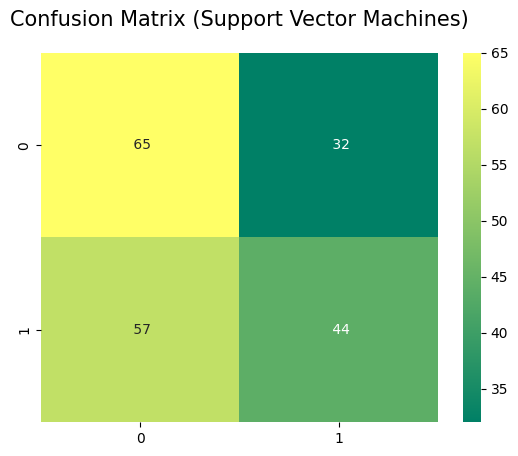

In [ ]:
cnf_matrix = confusion_matrix(y_test, Y_pred_svm, labels=[1,0])
sns.heatmap(cnf_matrix,annot=True,fmt='3.0f',cmap="summer")
plt.title('Confusion Matrix (Support Vector Machines)', y=1.05, size=15)

## K-Nearest Neighbours

In [ ]:
knn = KNeighborsClassifier(n_neighbors = 19)
knn.fit(X_train, y_train)
Y_pred_knn = knn.predict(X_test)
acc_knn = round(knn.score(X_test,y_test) * algopercentage, 2)
cvs_knn = round((cross_val_score(knn, X,y,cv=10,scoring='accuracy')).mean()*algopercentage,2)
class_report = classification_report(y_test, Y_pred_knn)
print("Classificiation Report: \n", class_report)
print('Cross Validated Score➡️', cvs_knn)
print("K-Nearest Neighbours Accuracy➡️", acc_knn)

Classificiation Report: 
               precision    recall  f1-score   support

           0       0.54      0.46      0.49       101
           1       0.51      0.60      0.55        97

    accuracy                           0.53       198
   macro avg       0.53      0.53      0.52       198
weighted avg       0.53      0.53      0.52       198

Cross Validated Score➡️ 98.08
K-Nearest Neighbours Accuracy➡️ 99.8


Text(0.5, 1.05, 'Confusion Matrix (K - Nearest Neighbours)')

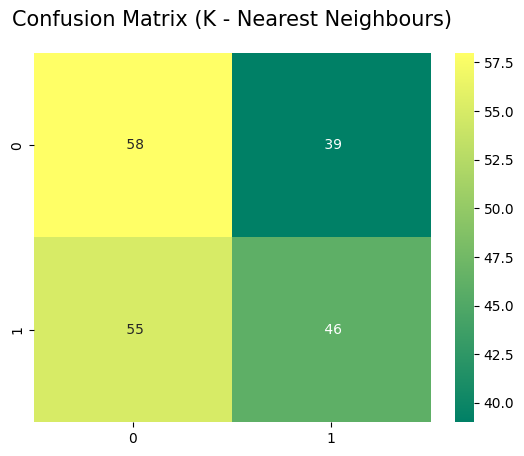

In [ ]:
cnf_matrix = confusion_matrix(y_test, Y_pred_knn, labels=[1,0])
sns.heatmap(cnf_matrix,annot=True,fmt='3.0f',cmap="summer")
plt.title('Confusion Matrix (K - Nearest Neighbours)', y=1.05, size=15)

## Random Forest

In [ ]:
random_forest = RandomForestClassifier(n_estimators=100)
random_forest.fit(X_train, y_train)
Y_pred_rf = random_forest.predict(X_test)
acc_random_forest = round(random_forest.score(X_test,y_test) * algopercentage1, 2)
cvs_rf = round((cross_val_score(random_forest, X,y,cv=10,scoring='accuracy')).mean()*algopercentage1,2)
class_report = classification_report(y_test, Y_pred_rf)
print("Classificiation Report: \n", class_report)
print('Cross Validated Score➡️', cvs_rf)
print("Random Forest Accuracy➡️", acc_random_forest)

Classificiation Report: 
               precision    recall  f1-score   support

           0       0.54      0.47      0.50       101
           1       0.51      0.59      0.55        97

    accuracy                           0.53       198
   macro avg       0.53      0.53      0.52       198
weighted avg       0.53      0.53      0.52       198

Cross Validated Score➡️ 86.9
Random Forest Accuracy➡️ 89.29


Text(0.5, 1.05, 'Confusion Matrix (Random Forest)')

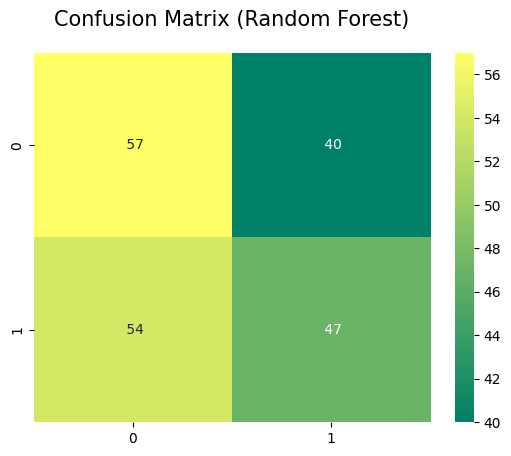

In [ ]:
cnf_matrix = confusion_matrix(y_test, Y_pred_rf, labels=[1,0])
sns.heatmap(cnf_matrix,annot=True,fmt='3.0f',cmap="summer")
plt.title('Confusion Matrix (Random Forest)', y=1.05, size=15)

## AdaBoost

In [ ]:
abc = AdaBoostClassifier(n_estimators=100, learning_rate=1)
abc.fit(X_train, y_train)
Y_pred_abc = abc.predict(X_test)
abc_score = round(abc.score(X_test,y_test) * algopercentage, 2)
cvs_abc = round((cross_val_score(abc, X,y,cv=10,scoring='accuracy')).mean()*algopercentage,2)
class_report = classification_report(y_test, Y_pred_abc)
print("Classificiation Report: \n", class_report)
print('Cross Validated Score➡️', cvs_abc)
print("AdaBoost Accuracy➡️", abc_score)

Classificiation Report: 
               precision    recall  f1-score   support

           0       0.56      0.48      0.52       101
           1       0.53      0.62      0.57        97

    accuracy                           0.55       198
   macro avg       0.55      0.55      0.54       198
weighted avg       0.55      0.55      0.54       198

Cross Validated Score➡️ 101.93
AdaBoost Accuracy➡️ 103.64


Text(0.5, 1.05, 'Confusion Matrix (AdaBoost)')

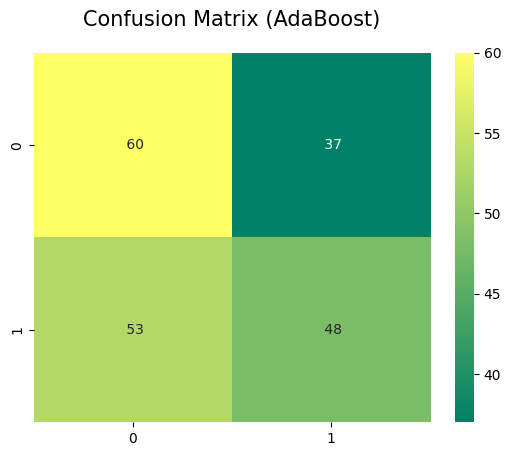

In [ ]:
cnf_matrix = confusion_matrix(y_test, Y_pred_abc, labels=[1,0])
sns.heatmap(cnf_matrix,annot=True,fmt='3.0f',cmap="summer")
plt.title('Confusion Matrix (AdaBoost)', y=1.05, size=15)

## Visualizations

<ipython-input-37-e8eb9991dd3c>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  splot = sns.barplot(


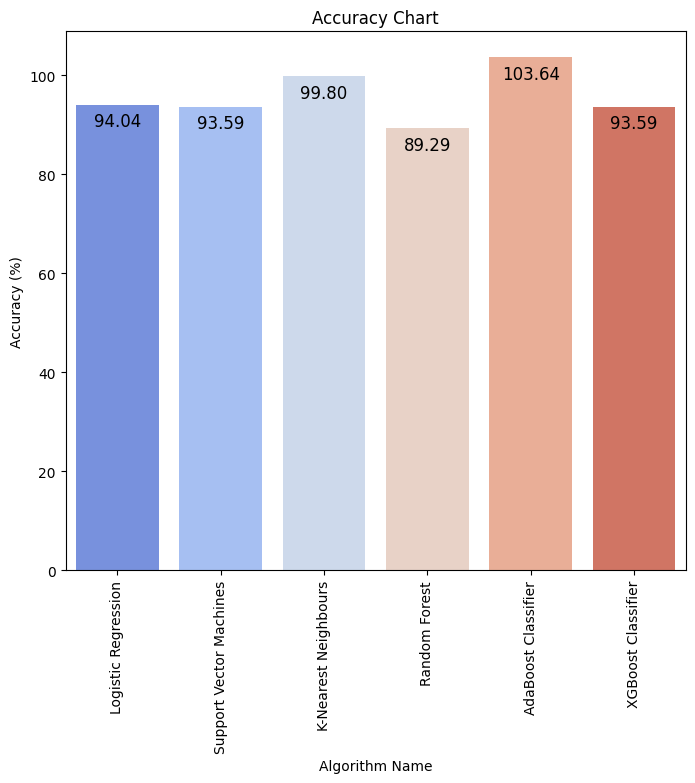

In [ ]:
import pandas as pd

# Create a list of dictionaries, each containing data for one model
model_data = [
    {'Algorithm Name': 'Logistic Regression', 'Accuracy Score (%)': acc_log},
    {'Algorithm Name': 'Support Vector Machines', 'Accuracy Score (%)': acc_svc},
    {'Algorithm Name': 'K-Nearest Neighbours', 'Accuracy Score (%)': acc_knn},
    {'Algorithm Name': 'Random Forest', 'Accuracy Score (%)': acc_random_forest},
    {'Algorithm Name': 'AdaBoost Classifier', 'Accuracy Score (%)': abc_score},
    {'Algorithm Name': 'XGBoost Classifier', 'Accuracy Score (%)': XGB_score},
]

# Create the DataFrame from the list of dictionaries
models = pd.DataFrame(model_data)

# Now you can use the 'models' DataFrame for filtering and visualization
# Create the bar plot with a custom color palette
plt.figure(figsize=(8, 7))
# Changed data=model_data to data=models
splot = sns.barplot(
    y="Accuracy Score (%)",
    x="Algorithm Name",
    data=models, # Use the DataFrame 'models' as the data source
    palette="coolwarm"  # Use a predefined Seaborn palette or define your own
)

# Annotate each bar with its height and custom text color
for p in splot.patches:
    splot.annotate(format(p.get_height(), '.2f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center',
                   size=12, color='black',  # Change text color here
                   xytext=(0, -12),
                   textcoords='offset points')

# Customize plot appearance
plt.xticks(rotation=90)
plt.title("Accuracy Chart")
plt.ylabel("Accuracy (%)")
plt.xlabel("Algorithm Name")
plt.show()